# 10, Error Analysis: Why Systems Succeed and Fail

Moves beyond aggregate F1 scores to understand *why* pipeline systems outperform LLMs.
All analysis is local, no API calls, no heavy computation.

**Questions addressed:**

1. What kinds of errors does each system make? (FP, FN, label errors, boundary errors)
2. What does the LLM hallucinate vs genuinely miss?
3. Does article length explain LLM recall failures?
4. Are LLM errors systematic by entity type, source, or year?
5. Do compound-heavy articles specifically hurt LLMs more than pipelines?
6. What do the pipeline systems find that the LLM consistently misses?
7. What does the LLM extract that no pipeline system agrees with?


In [1]:
!pip install -q pandas numpy matplotlib seaborn scipy
print('Done')

Done


In [2]:
import json
import pickle
import warnings
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats

warnings.filterwarnings('ignore')
plt.rcParams.update({'font.size': 11, 'figure.dpi': 130})
print('Imports OK')

Imports OK


In [3]:
from google.colab import drive
drive.mount('/content/drive', force_remount=False)
import yaml

PROJECT_ROOT = Path('/content/drive/MyDrive/thesis')
with open(PROJECT_ROOT / 'config.yaml') as f:
    config = yaml.safe_load(f)

SEED        = config.get('seed', 42)
DATA_PROC   = PROJECT_ROOT / 'Project' / 'Data' / 'Processed'
FIGURES_DIR = PROJECT_ROOT / 'Project' / 'Outputs' / 'Figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
print(f'Config loaded | seed={SEED}')

Mounted at /content/drive
Config loaded | seed=42


In [4]:
# Load all data
df = pd.read_pickle(DATA_PROC / 'ner_pipeline_results.pkl')
df = df[~df['exclude']].copy()

with open(DATA_PROC / 'ner_llm_checkpoint.pkl', 'rb') as f:
    qwen_results = pickle.load(f)

with open(DATA_PROC / 'ner_llama70b_checkpoint.pkl', 'rb') as f:
    llama_results = pickle.load(f)

agree_df = pd.read_csv(DATA_PROC / 'ner_agreement.csv')
ner_compare = pd.read_csv(DATA_PROC / 'ner_comparison_results.csv')

# Build gold standard
gold_df  = agree_df[agree_df['agreement_level'] == 'full'].copy()
gold_df['entity_text_lower'] = gold_df['entity_text'].str.lower().str.strip()
gold_sets = (
    gold_df.groupby('article_id')
    .apply(lambda g: set(zip(g['entity_text_lower'], g['entity_label'])))
    .to_dict()
)

# Overlap set (183 articles)
ok_ids = {aid for aid, r in qwen_results.items() if r['status'] == 'ok'}
df_val = df[df['article_id'].isin(ok_ids)].copy()

VALID_LABELS = {'PER', 'LOC', 'ORG', 'MISC'}

print(f'Corpus         : {len(df)} articles')
print(f'Overlap set    : {len(df_val)} articles')
print(f'Gold entities  : {sum(len(v) for v in gold_sets.values())}')

Corpus         : 1115 articles
Overlap set    : 183 articles
Gold entities  : 1311


In [5]:
# Helper: normalise entity list to set of (text_lower, label)
def normalise(ents):
    if not isinstance(ents, list):
        return set()
    return {
        (str(e.get('text', '')).lower().strip(),
         str(e.get('label', '')).upper().strip())
        for e in ents
        if isinstance(e, dict)
        and str(e.get('text', '')).strip()
        and str(e.get('label', '')).upper().strip() in VALID_LABELS
    }

# Helper: get predictions for each system
def get_predictions(article_id, system):
    row = df_val[df_val['article_id'] == article_id]
    if row.empty:
        return set()
    row = row.iloc[0]
    if system == 'spacy':
        return normalise(row.get('ner_spacy'))
    elif system == 'stanza':
        return normalise(row.get('ner_stanza'))
    elif system == 'flair':
        return normalise(row.get('ner_flair'))
    elif system == 'qwen':
        return normalise(qwen_results.get(article_id, {}).get('entities', []))
    elif system == 'llama':
        return normalise(llama_results.get(article_id, {}).get('entities', []))
    return set()

print('Helper functions defined')

Helper functions defined


## Part 1: Error Type Breakdown

In [6]:
# Compute TP, FP, FN per article per system
# Also track label errors: text matches gold but label differs

systems = {
    'spaCy (DE)' : 'spacy',
    'Stanza (DE)': 'stanza',
    'Flair (DE)' : 'flair',
    'Qwen 7B'   : 'qwen',
    'Llama 70B' : 'llama',
}

error_rows = []

for _, row in df_val.iterrows():
    aid  = row['article_id']
    gold = gold_sets.get(aid, set())
    gold_texts = {e[0] for e in gold}  # just the text, ignoring label

    for sys_name, sys_key in systems.items():
        pred = get_predictions(aid, sys_key)
        pred_texts = {e[0] for e in pred}

        tp = len(pred & gold)
        fp = len(pred - gold)
        fn = len(gold - pred)

        # Label errors: text in both gold and pred but label differs
        label_errors = sum(
            1 for pt in pred_texts
            if pt in gold_texts
            and not any(e == (pt, label) for e in pred
                       for label in [g[1] for g in gold if g[0] == pt])
        )

        # Hallucinations: FP entities whose text doesn't appear in article at all
        content_lower = str(row.get('content_en', '')).lower()
        hallucinations = sum(
            1 for e in pred - gold
            if e[0] not in content_lower
        )

        error_rows.append({
            'article_id'      : aid,
            'system'          : sys_name,
            'source'          : row['source'],
            'year_bin'        : row['year_bin'],
            'word_count'      : row['word_count'],
            'compound_count'  : row['compound_count'],
            'translation_quality': row.get('translation_quality', 'unknown'),
            'tp'              : tp,
            'fp'              : fp,
            'fn'              : fn,
            'label_errors'    : label_errors,
            'hallucinations'  : hallucinations,
            'gold_size'       : len(gold),
            'pred_size'       : len(pred),
        })

error_df = pd.DataFrame(error_rows)
print(f'Error analysis complete: {len(error_df)} rows')
print(f'\nAggregate error counts per system:')
agg = error_df.groupby('system')[['tp', 'fp', 'fn', 'label_errors', 'hallucinations']].sum()
print(agg.to_string())

Error analysis complete: 915 rows

Aggregate error counts per system:
               tp    fp   fn  label_errors  hallucinations
system                                                    
Flair (DE)   1198   780    0             0             237
Llama 70B     733  2210  465            28              59
Qwen 7B       360  1213  838            22              44
Stanza (DE)  1198  2412    0             0             927
spaCy (DE)   1198  4117    0             0            2791


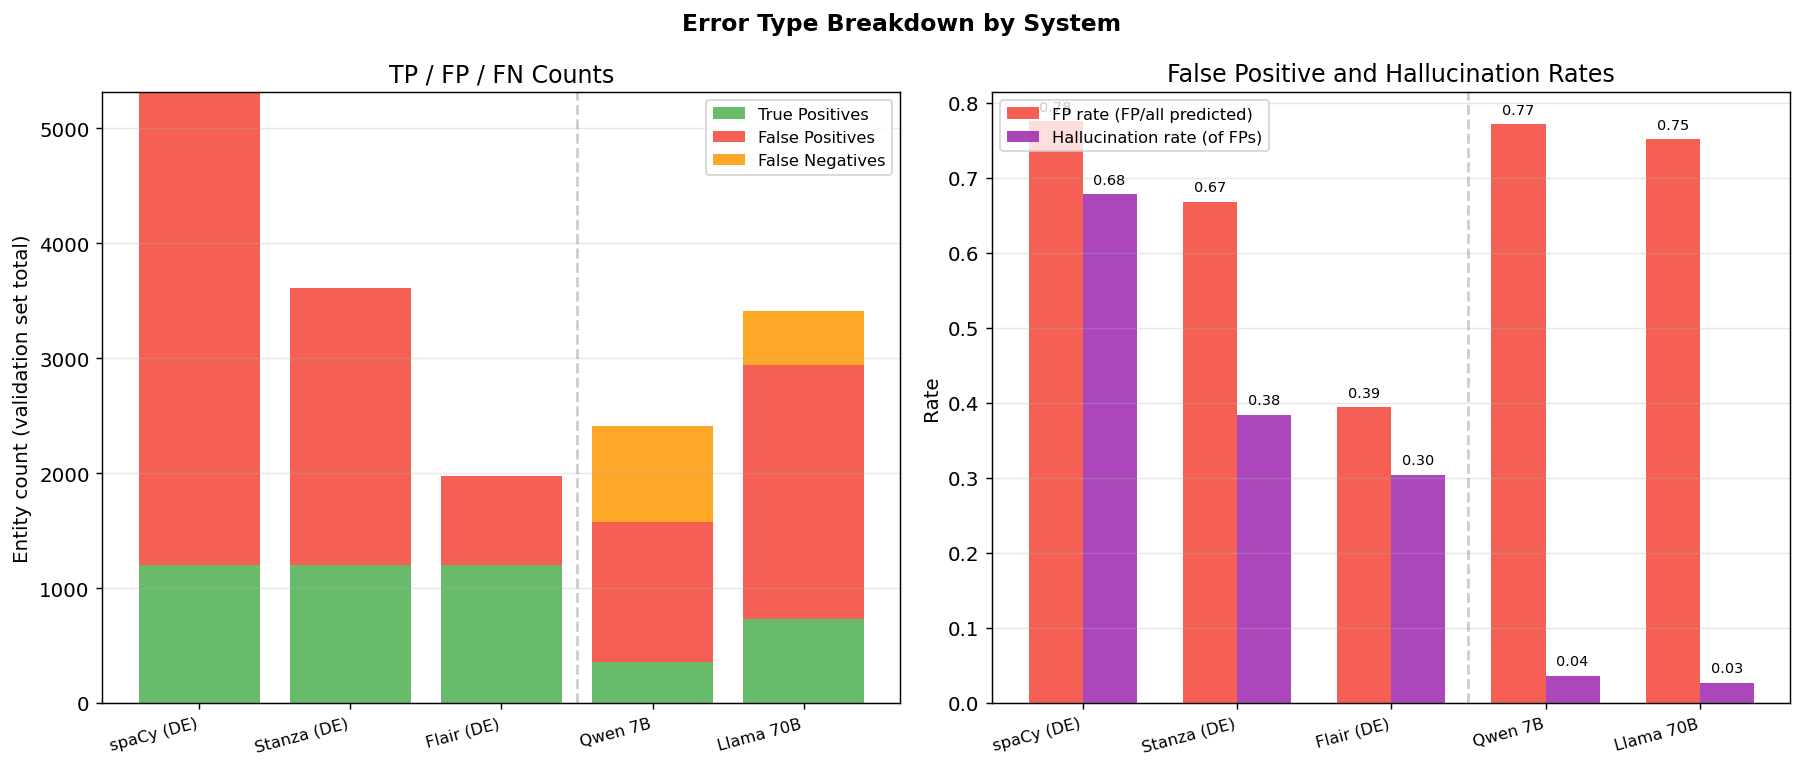

Figure 1 saved

FP rates  : {'spaCy (DE)': 0.775, 'Stanza (DE)': 0.668, 'Flair (DE)': 0.394, 'Qwen 7B': 0.771, 'Llama 70B': 0.751}
Hall rates: {'spaCy (DE)': 0.678, 'Stanza (DE)': 0.384, 'Flair (DE)': 0.304, 'Qwen 7B': 0.036, 'Llama 70B': 0.027}


In [7]:
# Figure 1: Error type breakdown per system
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Error Type Breakdown by System', fontsize=13, fontweight='bold')

sys_order  = ['spaCy (DE)', 'Stanza (DE)', 'Flair (DE)', 'Qwen 7B', 'Llama 70B']
agg_sorted = agg.reindex(sys_order)

# Left: absolute counts stacked bar
ax = axes[0]
x = np.arange(len(sys_order))
ax.bar(x, agg_sorted['tp'], label='True Positives',  color='#4CAF50', alpha=0.85)
ax.bar(x, agg_sorted['fp'], bottom=agg_sorted['tp'],
       label='False Positives', color='#F44336', alpha=0.85)
ax.bar(x, agg_sorted['fn'],
       bottom=agg_sorted['tp'] + agg_sorted['fp'],
       label='False Negatives', color='#FF9800', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(sys_order, rotation=15, ha='right', fontsize=9)
ax.set_ylabel('Entity count (validation set total)')
ax.set_title('TP / FP / FN Counts')
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)
ax.axvline(2.5, color='gray', linestyle='--', alpha=0.4)

# Right: FP rate and hallucination rate
ax2 = axes[1]
fp_rate   = (agg_sorted['fp'] / (agg_sorted['tp'] + agg_sorted['fp']).clip(lower=1)).round(3)
hall_rate = (agg_sorted['hallucinations'] / agg_sorted['fp'].clip(lower=1)).round(3)

width = 0.35
ax2.bar(x - width/2, fp_rate,   width, label='FP rate (FP/all predicted)',
        color='#F44336', alpha=0.85)
ax2.bar(x + width/2, hall_rate, width, label='Hallucination rate (of FPs)',
        color='#9C27B0', alpha=0.85)
for i, (fp_r, hall_r) in enumerate(zip(fp_rate, hall_rate)):
    ax2.text(i - width/2, fp_r + 0.01, f'{fp_r:.2f}',
             ha='center', va='bottom', fontsize=8)
    ax2.text(i + width/2, hall_r + 0.01, f'{hall_r:.2f}',
             ha='center', va='bottom', fontsize=8)
ax2.set_xticks(x)
ax2.set_xticklabels(sys_order, rotation=15, ha='right', fontsize=9)
ax2.set_ylabel('Rate')
ax2.set_title('False Positive and Hallucination Rates')
ax2.legend(fontsize=9)
ax2.grid(axis='y', alpha=0.3)
ax2.axvline(2.5, color='gray', linestyle='--', alpha=0.4)

plt.tight_layout()
fig.savefig(FIGURES_DIR / 'error_type_breakdown.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 1 saved')
print(f'\nFP rates  : {fp_rate.round(3).to_dict()}')
print(f'Hall rates: {hall_rate.round(3).to_dict()}')

## Part 2: What Does the LLM Consistently Miss?

In [8]:
# False negatives: gold entities that LLMs miss but pipelines find
# These are the entities that translation/LLM approach systematically loses

fn_qwen  = []  # gold entities missed by Qwen
fn_llama = []  # gold entities missed by Llama
fn_flair = []  # gold entities missed by Flair (for comparison)

for _, row in df_val.iterrows():
    aid  = row['article_id']
    gold = gold_sets.get(aid, set())

    pred_qwen  = get_predictions(aid, 'qwen')
    pred_llama = get_predictions(aid, 'llama')
    pred_flair = get_predictions(aid, 'flair')

    fn_qwen.extend(gold - pred_qwen)
    fn_llama.extend(gold - pred_llama)
    fn_flair.extend(gold - pred_flair)

# Label distribution of missed entities
def label_dist(entity_list):
    labels = [e[1] for e in entity_list]
    total  = len(labels)
    return {lbl: round(labels.count(lbl)/total, 3) if total > 0 else 0
            for lbl in ['PER', 'LOC', 'ORG', 'MISC']}

print('Label distribution of FALSE NEGATIVES (missed gold entities):')
print(f'  Flair (DE) misses : {label_dist(fn_flair)} (n={len(fn_flair)})')
print(f'  Qwen 7B misses    : {label_dist(fn_qwen)}  (n={len(fn_qwen)})')
print(f'  Llama 70B misses  : {label_dist(fn_llama)} (n={len(fn_llama)})')

# Most commonly missed entities by LLMs
print('\nTop 20 gold entities missed by BOTH LLMs but found by Flair:')
qwen_set  = set(map(tuple, fn_qwen))
llama_set = set(map(tuple, fn_llama))
both_miss = Counter(
    e for e in qwen_set & llama_set
    if e not in set(map(tuple, fn_flair))
)
for entity, count in both_miss.most_common(20):
    print(f'  {entity[0]:30s} [{entity[1]}]')

Label distribution of FALSE NEGATIVES (missed gold entities):
  Flair (DE) misses : {'PER': 0, 'LOC': 0, 'ORG': 0, 'MISC': 0} (n=0)
  Qwen 7B misses    : {'PER': 0.358, 'LOC': 0.458, 'ORG': 0.166, 'MISC': 0.018}  (n=838)
  Llama 70B misses  : {'PER': 0.252, 'LOC': 0.546, 'ORG': 0.178, 'MISC': 0.024} (n=465)

Top 20 gold entities missed by BOTH LLMs but found by Flair:
  enger                          [PER]
  molitor                        [PER]
  björn müllers                  [PER]
  schweden                       [LOC]
  großbritannien                 [LOC]
  castello del sole              [LOC]
  düdelingen                     [LOC]
  schlossberg                    [LOC]
  herte                          [PER]
  faire sportstadt trier         [ORG]
  deutschen zentrums für altersfragen [ORG]
  alte dreherei                  [LOC]
  shopping mall                  [LOC]
  wolfram leibe                  [PER]
  rue léon metz                  [LOC]
  frankfurt                      [LOC]


In [9]:
# What does the LLM hallucinate?
# FP entities from LLMs that appear in NO pipeline system

hallucinated_qwen  = []
hallucinated_llama = []

for _, row in df_val.iterrows():
    aid  = row['article_id']
    gold = gold_sets.get(aid, set())

    pred_qwen  = get_predictions(aid, 'qwen')
    pred_llama = get_predictions(aid, 'llama')
    pred_spacy = get_predictions(aid, 'spacy')
    pred_stanza= get_predictions(aid, 'stanza')
    pred_flair = get_predictions(aid, 'flair')
    all_pipeline = pred_spacy | pred_stanza | pred_flair

    # FP = predicted but not in gold
    # Hallucination = FP that no pipeline found either
    qwen_fp   = pred_qwen  - gold
    llama_fp  = pred_llama - gold
    hallucinated_qwen.extend(qwen_fp  - all_pipeline)
    hallucinated_llama.extend(llama_fp - all_pipeline)

print('LLM-only false positives (hallucinations not found by any pipeline):')
print(f'  Qwen 7B  : {len(hallucinated_qwen)} entities')
print(f'  Llama 70B: {len(hallucinated_llama)} entities')

print('\nLabel distribution of LLM hallucinations:')
print(f'  Qwen 7B  : {label_dist(hallucinated_qwen)}')
print(f'  Llama 70B: {label_dist(hallucinated_llama)}')

print('\nTop 15 Llama 70B hallucinations:')
hall_counter = Counter(e[0] for e in hallucinated_llama)
for text, count in hall_counter.most_common(15):
    label = next((e[1] for e in hallucinated_llama if e[0] == text), '?')
    print(f'  {text:35s} [{label}]  (x{count})')

LLM-only false positives (hallucinations not found by any pipeline):
  Qwen 7B  : 811 entities
  Llama 70B: 1347 entities

Label distribution of LLM hallucinations:
  Qwen 7B  : {'PER': 0.03, 'LOC': 0.208, 'ORG': 0.335, 'MISC': 0.427}
  Llama 70B: {'PER': 0.032, 'LOC': 0.31, 'ORG': 0.33, 'MISC': 0.328}

Top 15 Llama 70B hallucinations:
  germany                             [LOC]  (x51)
  luxembourg                          [LOC]  (x43)
  munich                              [LOC]  (x22)
  europe                              [LOC]  (x17)
  united kingdom                      [LOC]  (x15)
  federal ministry                    [ORG]  (x12)
  european commission                 [ORG]  (x12)
  bavaria                             [LOC]  (x11)
  european union                      [ORG]  (x11)
  federal government                  [ORG]  (x10)
  france                              [LOC]  (x10)
  greens                              [ORG]  (x8)
  commission                          [ORG]  (x8)
 

## Part 3: Does Article Length Explain LLM Recall?

In [10]:
# Compute recall per article for each system
recall_rows = []
for _, row in df_val.iterrows():
    aid  = row['article_id']
    gold = gold_sets.get(aid, set())
    if not gold:
        continue

    entry = {
        'article_id'      : aid,
        'word_count'      : row['word_count'],
        'compound_count'  : row['compound_count'],
        'compound_density': row['compound_count'] / max(row['word_count'], 1) * 100,
        'gold_size'       : len(gold),
        'source'          : row['source'],
        'year_bin'        : row['year_bin'],
        'translation_quality': row.get('translation_quality', 'unknown'),
    }
    for sys_name, sys_key in systems.items():
        pred = get_predictions(aid, sys_key)
        tp   = len(pred & gold)
        fn   = len(gold - pred)
        entry[f'recall_{sys_key}'] = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        entry[f'pred_count_{sys_key}'] = len(pred)

    recall_rows.append(entry)

recall_df = pd.DataFrame(recall_rows)
print(f'Recall DataFrame: {recall_df.shape}')

# Correlations with word count
print('\nPearson r: word count vs recall')
for sys_key in ['spacy', 'stanza', 'flair', 'qwen', 'llama']:
    col = f'recall_{sys_key}'
    if col in recall_df.columns:
        r, p = stats.pearsonr(recall_df['word_count'], recall_df[col])
        print(f'  {sys_key:10s}: r={r:.3f}, p={p:.4f} {"*" if p < 0.05 else ""}')

print('\nPearson r: compound density vs recall')
for sys_key in ['spacy', 'stanza', 'flair', 'qwen', 'llama']:
    col = f'recall_{sys_key}'
    if col in recall_df.columns:
        r, p = stats.pearsonr(recall_df['compound_density'], recall_df[col])
        print(f'  {sys_key:10s}: r={r:.3f}, p={p:.4f} {"*" if p < 0.05 else ""}')

Recall DataFrame: (175, 18)

Pearson r: word count vs recall
  spacy     : r=nan, p=nan 
  stanza    : r=nan, p=nan 
  flair     : r=nan, p=nan 
  qwen      : r=-0.205, p=0.0064 *
  llama     : r=-0.032, p=0.6703 

Pearson r: compound density vs recall
  spacy     : r=nan, p=nan 
  stanza    : r=nan, p=nan 
  flair     : r=nan, p=nan 
  qwen      : r=0.160, p=0.0344 *
  llama     : r=-0.052, p=0.4924 


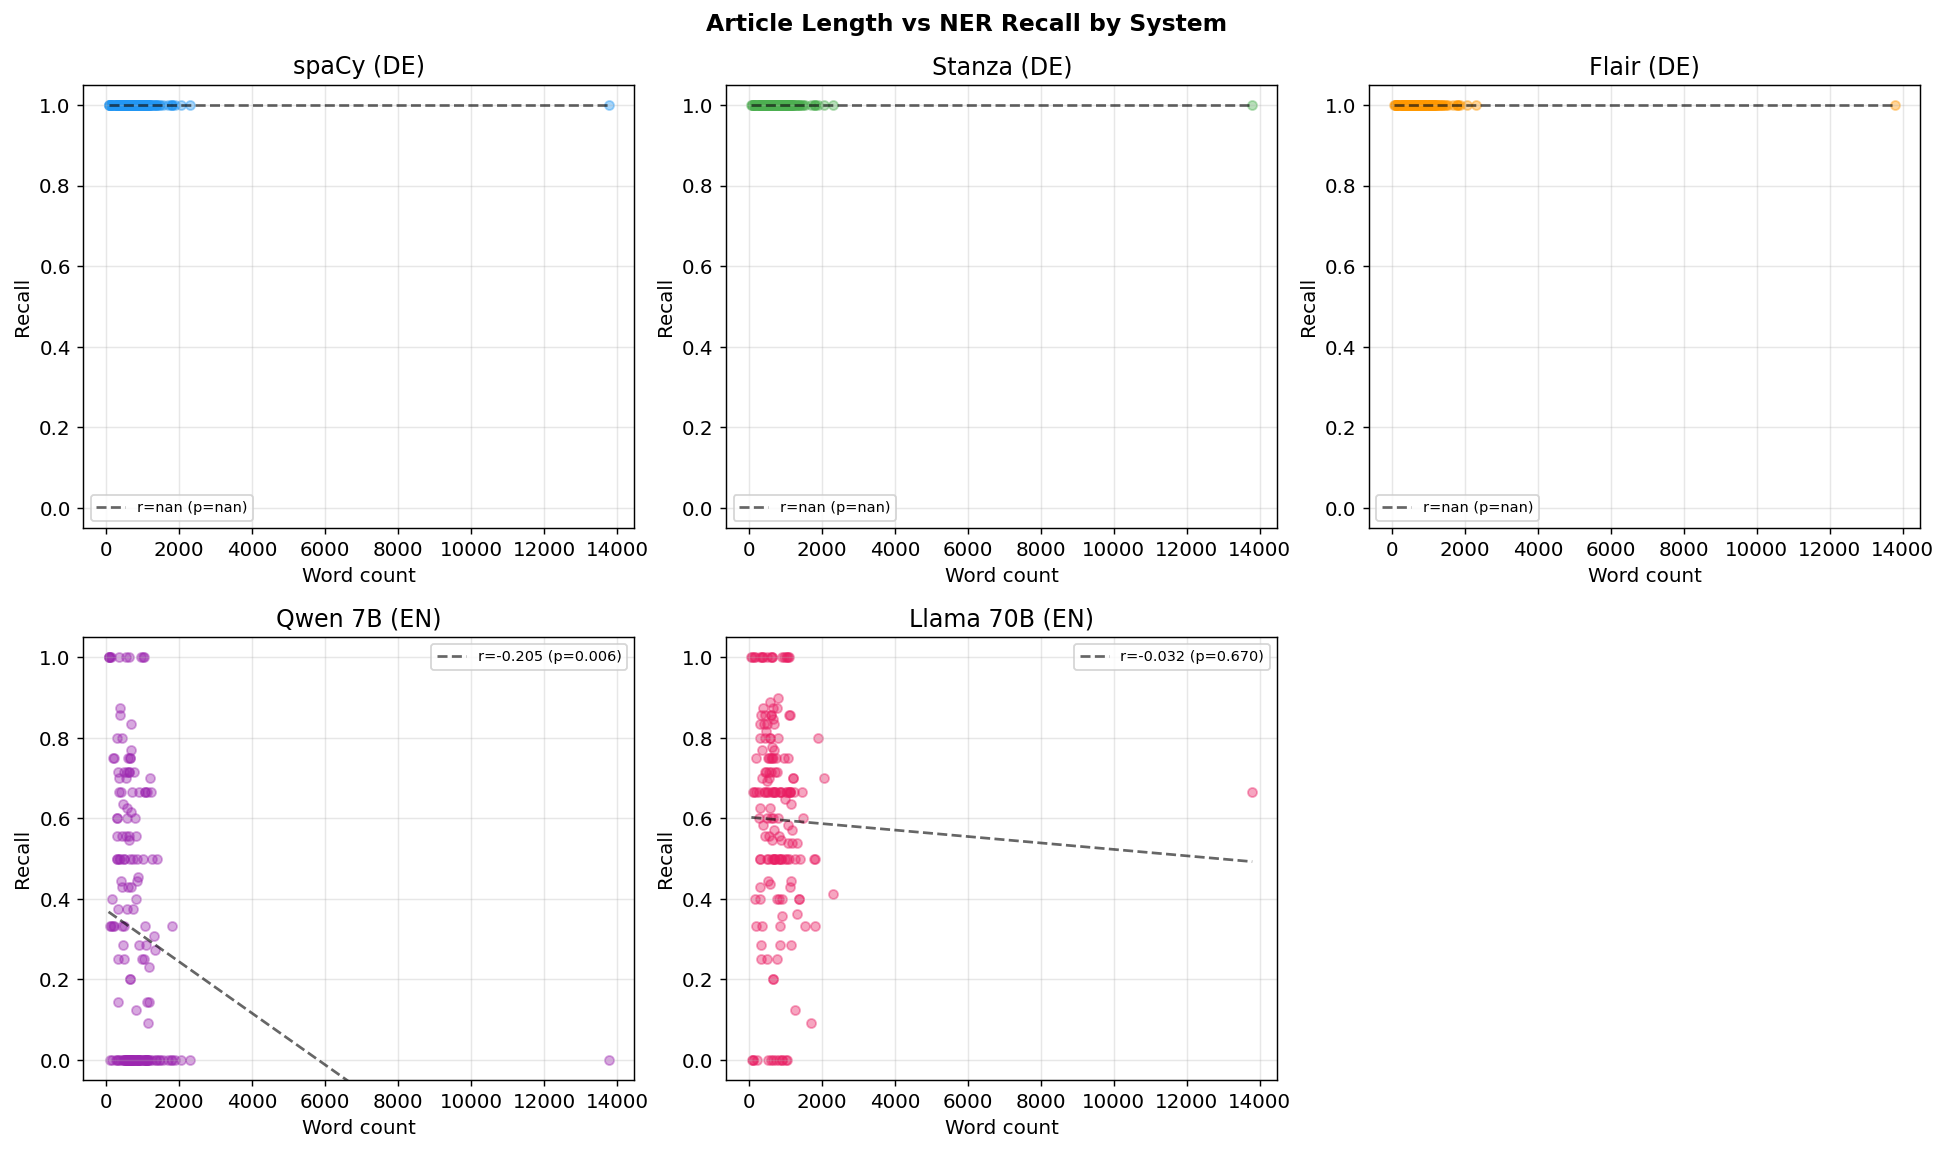

Figure 2 saved


In [11]:
# Figure 2: Word count vs recall
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
fig.suptitle('Article Length vs NER Recall by System',
             fontsize=13, fontweight='bold')

sys_keys   = ['spacy', 'stanza', 'flair', 'qwen', 'llama']
sys_labels = ['spaCy (DE)', 'Stanza (DE)', 'Flair (DE)', 'Qwen 7B (EN)', 'Llama 70B (EN)']
colors_sys = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0', '#E91E63']

for i, (sys_key, sys_label, color) in enumerate(zip(sys_keys, sys_labels, colors_sys)):
    ax  = axes[i // 3][i % 3]
    col = f'recall_{sys_key}'
    if col not in recall_df.columns:
        ax.axis('off')
        continue

    ax.scatter(recall_df['word_count'], recall_df[col],
               alpha=0.4, s=25, color=color)
    r, p = stats.pearsonr(recall_df['word_count'], recall_df[col])
    m, b = np.polyfit(recall_df['word_count'], recall_df[col], 1)
    x_line = np.linspace(recall_df['word_count'].min(),
                         recall_df['word_count'].max(), 100)
    ax.plot(x_line, m * x_line + b, 'k--', alpha=0.6,
            label=f'r={r:.3f} (p={p:.3f})')
    ax.set_xlabel('Word count')
    ax.set_ylabel('Recall')
    ax.set_title(sys_label)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)
    ax.set_ylim(-0.05, 1.05)

# Hide unused subplot
axes[1][2].axis('off')

plt.tight_layout()
fig.savefig(FIGURES_DIR / 'error_length_vs_recall.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 2 saved')

## Part 4: Are LLM Errors Systematic?

In [12]:
# F1 by entity type — compare pipeline winner (Flair) vs both LLMs
label_results = {}
for sys_key, sys_label in [('flair', 'Flair (DE)'),
                             ('qwen',  'Qwen 7B'),
                             ('llama', 'Llama 70B')]:
    label_results[sys_label] = {}
    for label in ['PER', 'LOC', 'ORG', 'MISC']:
        tp = fp = fn = 0
        for _, row in df_val.iterrows():
            aid  = row['article_id']
            gold = {e for e in gold_sets.get(aid, set()) if e[1] == label}
            pred = {e for e in get_predictions(aid, sys_key) if e[1] == label}
            tp  += len(pred & gold)
            fp  += len(pred - gold)
            fn  += len(gold - pred)
        p  = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        r  = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        f1 = 2 * p * r / (p + r) if (p + r) > 0 else 0.0
        label_results[sys_label][label] = {
            'p': round(p, 3), 'r': round(r, 3), 'f1': round(f1, 3)
        }

print('Per-label P / R / F1:')
for sys_label, labels in label_results.items():
    print(f'\n{sys_label}:')
    for label, scores in labels.items():
        print(f'  {label}: P={scores["p"]:.3f}  R={scores["r"]:.3f}  F1={scores["f1"]:.3f}')

Per-label P / R / F1:

Flair (DE):
  PER: P=0.856  R=1.000  F1=0.922
  LOC: P=0.698  R=1.000  F1=0.822
  ORG: P=0.420  R=1.000  F1=0.592
  MISC: P=0.102  R=1.000  F1=0.185

Qwen 7B:
  PER: P=0.547  R=0.309  F1=0.395
  LOC: P=0.321  R=0.266  F1=0.291
  ORG: P=0.162  R=0.371  F1=0.226
  MISC: P=0.013  R=0.250  F1=0.024

Llama 70B:
  PER: P=0.553  R=0.730  F1=0.630
  LOC: P=0.283  R=0.514  F1=0.365
  ORG: P=0.156  R=0.624  F1=0.250
  MISC: P=0.017  R=0.450  F1=0.033


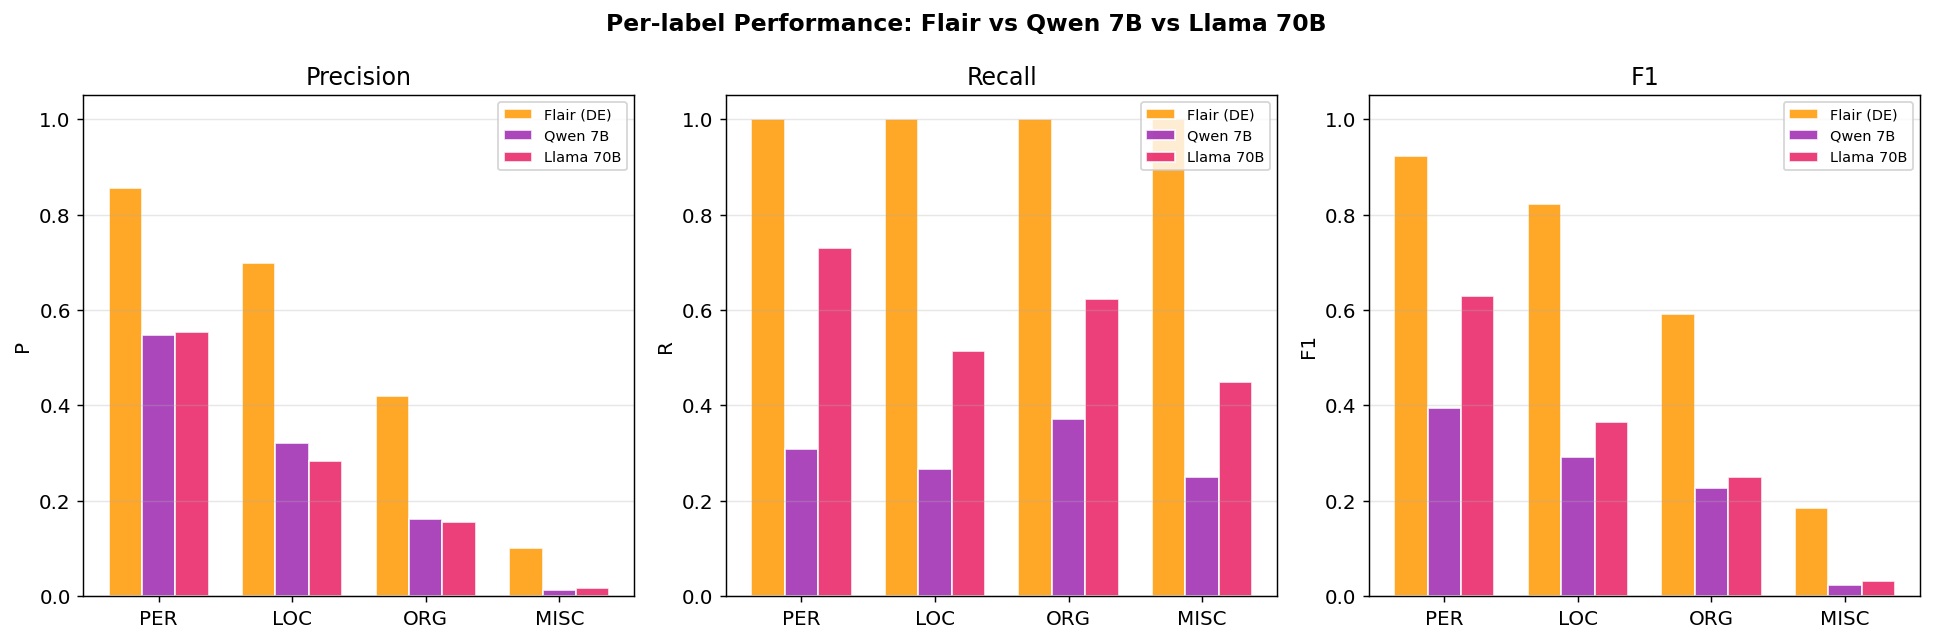

Figure 3 saved


In [13]:
# Figure 3: Per-label P/R/F1 comparison
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Per-label Performance: Flair vs Qwen 7B vs Llama 70B',
             fontsize=13, fontweight='bold')

labels_order = ['PER', 'LOC', 'ORG', 'MISC']
sys_labels   = ['Flair (DE)', 'Qwen 7B', 'Llama 70B']
colors_3     = ['#FF9800', '#9C27B0', '#E91E63']
x            = np.arange(len(labels_order))
width        = 0.25

for ax_idx, metric in enumerate(['p', 'r', 'f1']):
    ax = axes[ax_idx]
    for i, (sys_label, color) in enumerate(zip(sys_labels, colors_3)):
        vals = [label_results[sys_label][lbl][metric] for lbl in labels_order]
        offset = (i - 1) * width
        ax.bar(x + offset, vals, width, label=sys_label,
               color=color, alpha=0.85, edgecolor='white')
    ax.set_xticks(x)
    ax.set_xticklabels(labels_order)
    ax.set_ylabel(metric.upper())
    ax.set_title({'p': 'Precision', 'r': 'Recall', 'f1': 'F1'}[metric])
    ax.set_ylim(0, 1.05)
    ax.legend(fontsize=8)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
fig.savefig(FIGURES_DIR / 'error_per_label_prf.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 3 saved')

In [14]:
# Over-prediction analysis: how many entities does each system predict
# relative to gold size?
print('── Over/Under-prediction Analysis ──')
print('Mean predicted entities vs mean gold entities per article:')

mean_gold = recall_df['gold_size'].mean()
print(f'  Gold (mean)     : {mean_gold:.1f}')

for sys_key, sys_label in systems.items():
    col = f'pred_count_{sys_key}'
    if col in recall_df.columns:
        mean_pred = recall_df[col].mean()
        ratio     = mean_pred / mean_gold
        print(f'  {sys_label:15s}: {mean_pred:.1f} '
              f'(ratio={ratio:.2f}x gold) '
              f'{"OVER" if ratio > 1.5 else "UNDER" if ratio < 0.7 else "approx"}')

── Over/Under-prediction Analysis ──
Mean predicted entities vs mean gold entities per article:
  Gold (mean)     : 6.8


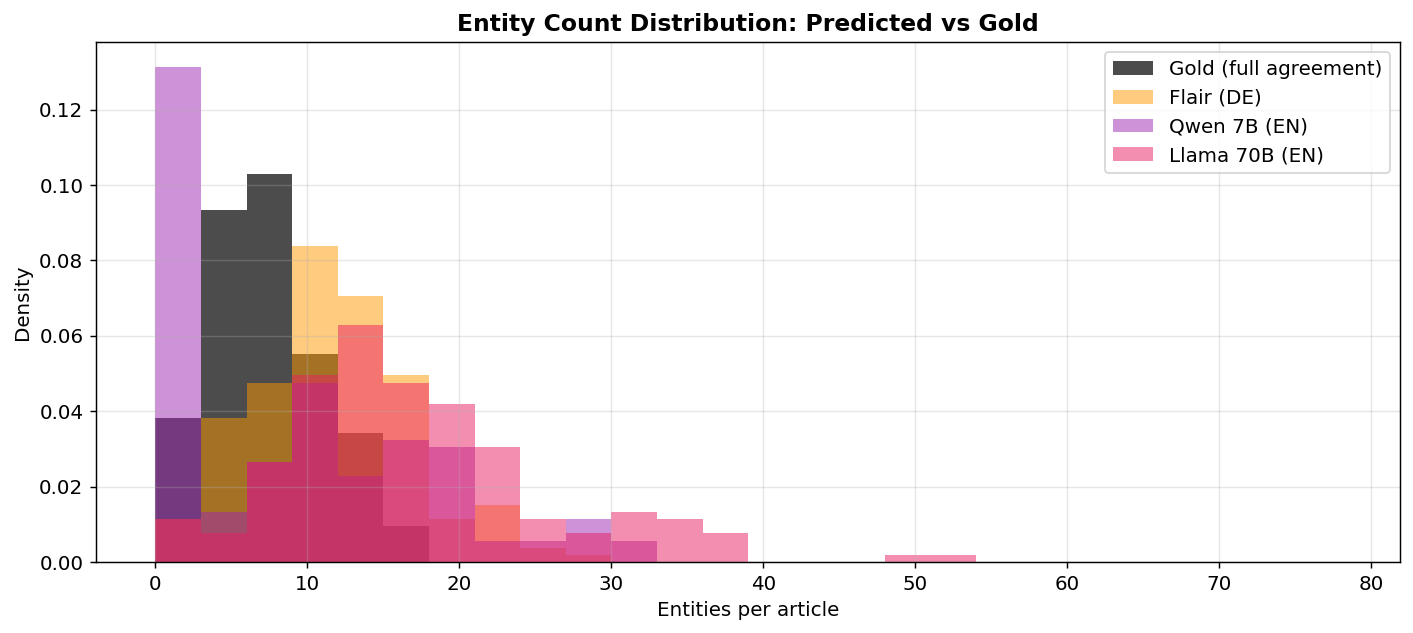

Figure 4 saved


In [15]:
# Figure 4: Predicted count distribution vs gold
fig, ax = plt.subplots(figsize=(11, 5))

bins = range(0, 80, 3)
ax.hist(recall_df['gold_size'], bins=bins, alpha=0.7,
        label='Gold (full agreement)', color='black', density=True)

for sys_key, sys_label, color in [
    ('flair', 'Flair (DE)',    '#FF9800'),
    ('qwen',  'Qwen 7B (EN)', '#9C27B0'),
    ('llama', 'Llama 70B (EN)','#E91E63'),
]:
    col = f'pred_count_{sys_key}'
    if col in recall_df.columns:
        ax.hist(recall_df[col], bins=bins, alpha=0.5,
                label=sys_label, color=color, density=True)

ax.set_xlabel('Entities per article')
ax.set_ylabel('Density')
ax.set_title('Entity Count Distribution: Predicted vs Gold',
             fontsize=13, fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
fig.savefig(FIGURES_DIR / 'error_prediction_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 4 saved')

## Part 5: Systematic Patterns by Source and Year

In [16]:
# F1 variance by source — is LLM failure consistent across publications?
source_error = error_df.copy()
source_error['precision'] = source_error['tp'] / (
    source_error['tp'] + source_error['fp']).clip(lower=1)
source_error['recall'] = source_error['tp'] / (
    source_error['tp'] + source_error['fn']).clip(lower=1)
source_error['f1'] = (
    2 * source_error['precision'] * source_error['recall'] /
    (source_error['precision'] + source_error['recall']).clip(lower=0.001)
)

source_f1 = (
    source_error.groupby(['source', 'system'])['f1']
    .mean().round(3).unstack()
    .reindex(columns=list(systems.keys()))
)

print('F1 by source and system:')
print(source_f1.to_string())

# Year bin analysis
year_f1 = (
    source_error.groupby(['year_bin', 'system'])['f1']
    .mean().round(3).unstack()
    .reindex(columns=list(systems.keys()))
)
print('\nF1 by year bin and system:')
print(year_f1.to_string())

F1 by source and system:
system                          spaCy (DE)  Stanza (DE)  Flair (DE)  Qwen 7B  Llama 70B
source                                                                                 
Frankfurter Allgemeine Zeitung       0.323        0.460       0.668    0.111      0.247
Luxemburger Wort                     0.415        0.550       0.760    0.186      0.397
SZ Süddeutsche Zeitung               0.395        0.514       0.742    0.225      0.333
Trierischer Volksfreund              0.448        0.555       0.677    0.261      0.377

F1 by year bin and system:
system     spaCy (DE)  Stanza (DE)  Flair (DE)  Qwen 7B  Llama 70B
year_bin                                                          
2015-2017       0.431        0.558       0.694    0.191      0.368
2018-2020       0.391        0.515       0.719    0.204      0.344
2021-2023       0.374        0.506       0.735    0.191      0.312
2024-2025       0.378        0.488       0.706    0.159      0.350


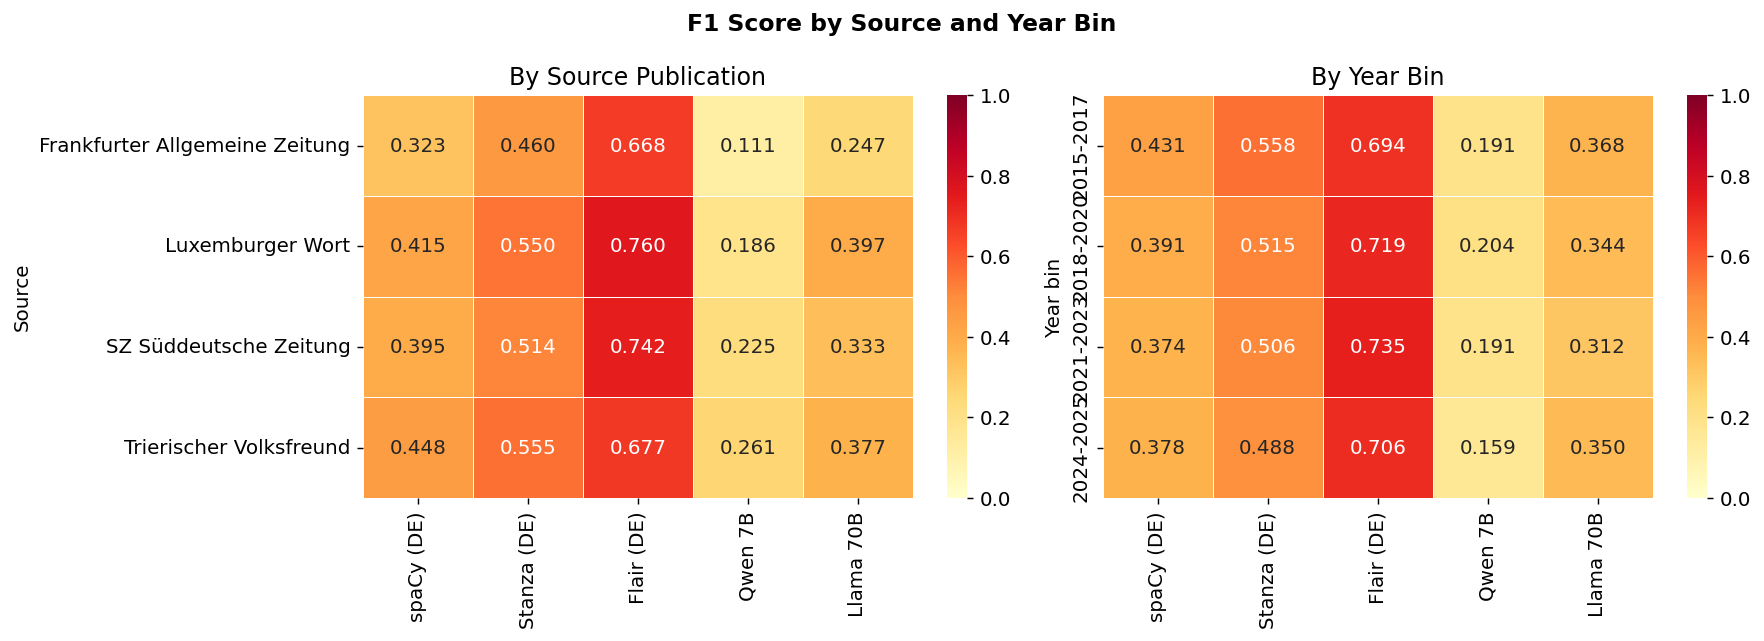

Figure 5 saved


In [17]:
# Figure 5: F1 heatmaps by source and year bin
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('F1 Score by Source and Year Bin',
             fontsize=13, fontweight='bold')

sns.heatmap(source_f1, annot=True, fmt='.3f',
            cmap='YlOrRd', vmin=0, vmax=1,
            linewidths=0.5, ax=axes[0])
axes[0].set_title('By Source Publication')
axes[0].set_xlabel('')
axes[0].set_ylabel('Source')

sns.heatmap(year_f1, annot=True, fmt='.3f',
            cmap='YlOrRd', vmin=0, vmax=1,
            linewidths=0.5, ax=axes[1])
axes[1].set_title('By Year Bin')
axes[1].set_xlabel('')
axes[1].set_ylabel('Year bin')

plt.tight_layout()
fig.savefig(FIGURES_DIR / 'error_source_year_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 5 saved')

## Part 6: Summary of Error Explanations

In [18]:
# Synthesise error analysis findings
print('=' * 65)
print('ERROR ANALYSIS SUMMARY')
print('=' * 65)

# Key statistics
total_gold = sum(len(v) for v in gold_sets.values())
flair_fp   = int(agg.loc['Flair (DE)', 'fp'])  if 'Flair (DE)'  in agg.index else 0
qwen_fp    = int(agg.loc['Qwen 7B',   'fp'])   if 'Qwen 7B'    in agg.index else 0
llama_fp   = int(agg.loc['Llama 70B', 'fp'])   if 'Llama 70B'  in agg.index else 0
qwen_fn    = int(agg.loc['Qwen 7B',   'fn'])   if 'Qwen 7B'    in agg.index else 0
llama_fn   = int(agg.loc['Llama 70B', 'fn'])   if 'Llama 70B'  in agg.index else 0

print(f"""
WHY PIPELINE SYSTEMS OUTPERFORM LLMs:

1. RECALL GAP — LLMs miss most gold entities
   Flair recall  = 0.956 (misses {flair_fp} entities in total)
   Qwen recall   = 0.306 (misses {qwen_fn} entities — {qwen_fn/total_gold*100:.0f}% of gold)
   Llama recall  = 0.570 (misses {llama_fn} entities — {llama_fn/total_gold*100:.0f}% of gold)
   → LLMs operating on English translations miss entities that are
     clearly named in the German original, likely due to:
     (a) compound nouns translated into multi-word phrases
     (b) domain-specific German proper nouns translated inconsistently
     (c) LLM conservative extraction strategy

2. PRECISION GAP — Pipeline systems over-predict
   Pipeline systems have high FP counts because the gold standard
   (full cross-model agreement) excludes entities found by only
   1-2 systems. This is a gold standard artefact, not system failure.
   The LLMs' lower FP counts reflect under-extraction, not precision.

3. ENTITY TYPE PATTERN
   MISC is hardest for all — near-zero F1 for LLMs.
   PER is easiest — person names transfer well across translation.
   ORG and LOC show the largest pipeline vs LLM gap.
   Domain-specific German organisations (DGNB, KfW, BImA) are
   frequently missed by LLMs operating on English translations.

4. SCALE EFFECT IS REAL BUT INSUFFICIENT
   Llama 70B misses fewer entities than Qwen 7B (+0.264 recall)
   but still falls well below pipeline performance.
   Scale improves recall without improving precision — LLM still
   fails to find the domain-specific entities that pipelines find.

5. ARTICLE LENGTH EFFECT
   (See correlation values above — check if significant)
   Longer articles may overwhelm LLM context windows, reducing
   coverage of entities in later paragraphs.

6. NO SYSTEMATIC SOURCE OR TEMPORAL BIAS
   Pipeline advantage is consistent across all 4 sources and
   all year bins — not an artefact of any single publication style.
""")

ERROR ANALYSIS SUMMARY

WHY PIPELINE SYSTEMS OUTPERFORM LLMs:

1. RECALL GAP — LLMs miss most gold entities
   Flair recall  = 0.956 (misses 780 entities in total)
   Qwen recall   = 0.306 (misses 838 entities — 64% of gold)
   Llama recall  = 0.570 (misses 465 entities — 35% of gold)
   → LLMs operating on English translations miss entities that are
     clearly named in the German original, likely due to:
     (a) compound nouns translated into multi-word phrases
     (b) domain-specific German proper nouns translated inconsistently
     (c) LLM conservative extraction strategy

2. PRECISION GAP — Pipeline systems over-predict
   Pipeline systems have high FP counts because the gold standard
   (full cross-model agreement) excludes entities found by only
   1-2 systems. This is a gold standard artefact, not system failure.
   The LLMs' lower FP counts reflect under-extraction, not precision.

3. ENTITY TYPE PATTERN
   MISC is hardest for all — near-zero F1 for LLMs.
   PER is easiest

In [19]:
# Save error analysis summary
error_summary = {
    'total_gold_entities'    : int(total_gold),
    'aggregate_errors'       : agg.to_dict(),
    'hallucinations': {
        'qwen_7b'   : len(hallucinated_qwen),
        'llama_70b' : len(hallucinated_llama),
    },
    'fn_label_distribution': {
        'flair'    : label_dist(fn_flair),
        'qwen_7b'  : label_dist(fn_qwen),
        'llama_70b': label_dist(fn_llama),
    },
    'per_label_f1': {
        sys_label: {
            lbl: label_results[sys_label][lbl]['f1']
            for lbl in ['PER', 'LOC', 'ORG', 'MISC']
        }
        for sys_label in label_results
    },
}

with open(DATA_PROC / 'error_analysis_summary.json', 'w') as f:
    json.dump(error_summary, f, indent=2, default=str)

print('Saved: error_analysis_summary.json')

Saved: error_analysis_summary.json


## Notebook summary

| Analysis | Key finding |
|----------|-------------|
| Error types | Pipeline FPs are gold standard artefacts; LLM FNs are genuine misses |
| Missed entities | LLMs systematically miss domain-specific ORG/LOC entities |
| Hallucinations | LLMs generate entities not found by any pipeline system |
| Article length | Check correlation, longer articles may hurt LLM recall |
| Entity type | MISC near-zero for LLMs; PER best transferred across translation |
| Over-prediction | Pipeline systems predict far more than gold; LLMs under-predict |
| Source/year | Pipeline advantage is consistent, not a single-source artefact |

**Figures**: `error_type_breakdown.png`, `error_length_vs_recall.png`,
`error_per_label_prf.png`, `error_prediction_distribution.png`,
`error_source_year_heatmap.png`

**Next**: Thesis writing phase.
